# 🏢 Business Formation Trends & Market Segmentation for Compliance Services in India
    Source: Ministry of Corporate Affairs

## 📦 Section 1 — Imports & Configuration

In [1]:
# Importing necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.ticker as mticker

## 📂 Data ingestion and data prepration

In [2]:
folder_path = R"D:\Downloads\MCA Data"

csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
print(f"Total CSV files: {len(csv_files)}")

all_dfs = []
for file in csv_files:
    df = pd.read_csv(os.path.join(folder_path, file), low_memory=False)
    df['State'] = file.replace('.csv', '')
    all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True)
print(f"Shape: {merged_df.shape}")
merged_df.head()

Total CSV files: 37
Shape: (2458152, 17)


,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State
0,U55100AN2009PTC000115,U AND I RESORTS PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,989630.0,2009-06-18,"HAVELOCK,PORT BLAIR,Andaman and Nicobar Island...",Unlisted,Active,andaman and nicobar islands,Indian,55100,Trading,andaman and nicobar islands
1,U55200AN2021PTC005554,JUNGLEVILLA RESORT & SPA PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1500000.0,100000.0,2021-10-13,"C/O BINITH DAS, 01, OPP. GOLDEN PEBBLE GOVIN...",Unlisted,Active,andaman and nicobar islands,Indian,55200,Trading,andaman and nicobar islands
2,U55209AN2018PTC005409,CORAL ISLAND BEACH RESORT PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,2000000.0,200000.0,2018-05-31,"GOVINDA NAGAR PORT BLAIR SOUTH ANDAMAN,PORT ...",Unlisted,Active,andaman and nicobar islands,Indian,55209,Trading,andaman and nicobar islands
3,U63031AN2019PTC005474,INFO INDIA TOUR AND HOLIDAYS PRIVATE LIMITED,ROC Chennai,Company limited by shares,Non-government company,Private,10000.0,10000.0,2019-11-21,"C/o Kulandai Velu, C-18, V/Nagar Bambooflat,...",Unlisted,Active,andaman and nicobar islands,Indian,63031,"Transport, storage and Communications",andaman and nicobar islands
4,U63040AN1999PTC000061,ANDAMAN TOURIST COTTAGE PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,10000.0,1999-04-26,"Babu Lane Port Blair,NA,Andaman and Nicobar ...",Unlisted,Strike Off,andaman and nicobar islands,Indian,63040,"Transport, storage and Communications",andaman and nicobar islands


In [3]:
# Reference columns from first file
first_file_path = os.path.join(folder_path, csv_files[0])
reference_columns = list(pd.read_csv(first_file_path, nrows=0).columns)

mismatch_files = []

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    columns = list(pd.read_csv(file_path, nrows=0).columns)

    if columns != reference_columns:
        mismatch_files.append(file)

# Final result
if len(mismatch_files) == 0:
    print("✅ All CSV files have the same columns")
else:
    print("❌ Files with different columns:")
    for file in mismatch_files:
        print(file)

✅ All CSV files have the same columns


In [4]:
all_dfs = []

for file in csv_files:
    
    file_path = os.path.join(folder_path, file)
    
    df = pd.read_csv(file_path, low_memory=False)
    
    state_name = file.replace(".csv", "")
    df["State"] = state_name
    
    all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True)

print("Total rows:", len(merged_df))
print("Total columns:", merged_df.shape[1])

Total rows: 2458152
Total columns: 17


In [5]:
merged_df.head()

,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State
0,U55100AN2009PTC000115,U AND I RESORTS PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,989630.0,2009-06-18,"HAVELOCK,PORT BLAIR,Andaman and Nicobar Island...",Unlisted,Active,andaman and nicobar islands,Indian,55100,Trading,andaman and nicobar islands
1,U55200AN2021PTC005554,JUNGLEVILLA RESORT & SPA PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1500000.0,100000.0,2021-10-13,"C/O BINITH DAS, 01, OPP. GOLDEN PEBBLE GOVIN...",Unlisted,Active,andaman and nicobar islands,Indian,55200,Trading,andaman and nicobar islands
2,U55209AN2018PTC005409,CORAL ISLAND BEACH RESORT PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,2000000.0,200000.0,2018-05-31,"GOVINDA NAGAR PORT BLAIR SOUTH ANDAMAN,PORT ...",Unlisted,Active,andaman and nicobar islands,Indian,55209,Trading,andaman and nicobar islands
3,U63031AN2019PTC005474,INFO INDIA TOUR AND HOLIDAYS PRIVATE LIMITED,ROC Chennai,Company limited by shares,Non-government company,Private,10000.0,10000.0,2019-11-21,"C/o Kulandai Velu, C-18, V/Nagar Bambooflat,...",Unlisted,Active,andaman and nicobar islands,Indian,63031,"Transport, storage and Communications",andaman and nicobar islands
4,U63040AN1999PTC000061,ANDAMAN TOURIST COTTAGE PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,10000.0,1999-04-26,"Babu Lane Port Blair,NA,Andaman and Nicobar ...",Unlisted,Strike Off,andaman and nicobar islands,Indian,63040,"Transport, storage and Communications",andaman and nicobar islands


# 📊 EDA (Exporatory data analysis)

In [6]:
# Displaying the first few rows of the merged DataFrame

merged_df.head()

,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State
0,U55100AN2009PTC000115,U AND I RESORTS PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,989630.0,2009-06-18,"HAVELOCK,PORT BLAIR,Andaman and Nicobar Island...",Unlisted,Active,andaman and nicobar islands,Indian,55100,Trading,andaman and nicobar islands
1,U55200AN2021PTC005554,JUNGLEVILLA RESORT & SPA PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1500000.0,100000.0,2021-10-13,"C/O BINITH DAS, 01, OPP. GOLDEN PEBBLE GOVIN...",Unlisted,Active,andaman and nicobar islands,Indian,55200,Trading,andaman and nicobar islands
2,U55209AN2018PTC005409,CORAL ISLAND BEACH RESORT PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,2000000.0,200000.0,2018-05-31,"GOVINDA NAGAR PORT BLAIR SOUTH ANDAMAN,PORT ...",Unlisted,Active,andaman and nicobar islands,Indian,55209,Trading,andaman and nicobar islands
3,U63031AN2019PTC005474,INFO INDIA TOUR AND HOLIDAYS PRIVATE LIMITED,ROC Chennai,Company limited by shares,Non-government company,Private,10000.0,10000.0,2019-11-21,"C/o Kulandai Velu, C-18, V/Nagar Bambooflat,...",Unlisted,Active,andaman and nicobar islands,Indian,63031,"Transport, storage and Communications",andaman and nicobar islands
4,U63040AN1999PTC000061,ANDAMAN TOURIST COTTAGE PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,10000.0,1999-04-26,"Babu Lane Port Blair,NA,Andaman and Nicobar ...",Unlisted,Strike Off,andaman and nicobar islands,Indian,63040,"Transport, storage and Communications",andaman and nicobar islands


In [7]:
# Displaying the shape of the merged DataFrame

merged_df.shape

(2458152, 17)

In [8]:
# Displaying the column names of the merged DataFrame

merged_df.columns

Index(['CIN', 'CompanyName', 'CompanyROCcode', 'CompanyCategory',
       'CompanySubCategory', 'CompanyClass', 'AuthorizedCapital',
       'PaidupCapital', 'CompanyRegistrationdate_date',
       'Registered_Office_Address', 'Listingstatus', 'CompanyStatus',
       'CompanyStateCode', 'CompanyIndian/Foreign Company', 'nic_code',
       'CompanyIndustrialClassification', 'State'],
      dtype='object')

In [9]:
# Displaying the data types and non-null counts of the merged DataFrame

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2458152 entries, 0 to 2458151
Data columns (total 17 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   CIN                              object 
 1   CompanyName                      object 
 2   CompanyROCcode                   object 
 3   CompanyCategory                  object 
 4   CompanySubCategory               object 
 5   CompanyClass                     object 
 6   AuthorizedCapital                float64
 7   PaidupCapital                    float64
 8   CompanyRegistrationdate_date     object 
 9   Registered_Office_Address        object 
 10  Listingstatus                    object 
 11  CompanyStatus                    object 
 12  CompanyStateCode                 object 
 13  CompanyIndian/Foreign Company    object 
 14  nic_code                         object 
 15  CompanyIndustrialClassification  object 
 16  State                            object 
dtypes: float

In [10]:
# Converting 'CompanyRegistrationdate_date' to datetime format

merged_df['CompanyRegistrationdate_date'] = pd.to_datetime(merged_df['CompanyRegistrationdate_date'], format='%Y-%m-%d')

In [11]:
# Checking for missing values in the merged DataFrame

merged_df.isnull().sum()

CIN                                 0
CompanyName                         0
CompanyROCcode                      0
CompanyCategory                     0
CompanySubCategory                  0
CompanyClass                        0
AuthorizedCapital                   0
PaidupCapital                       0
CompanyRegistrationdate_date        0
Registered_Office_Address          60
Listingstatus                       0
CompanyStatus                       0
CompanyStateCode                    0
CompanyIndian/Foreign Company       0
nic_code                            0
CompanyIndustrialClassification     0
State                               0
dtype: int64

In [12]:
print("total companies registered in india:", merged_df['CIN'].nunique())
print("the data ranges from", merged_df['CompanyRegistrationdate_date'].min().date(), "to", merged_df['CompanyRegistrationdate_date'].max().date())

total companies registered in india: 2393339
the data ranges from 1857-03-25 to 2025-05-05


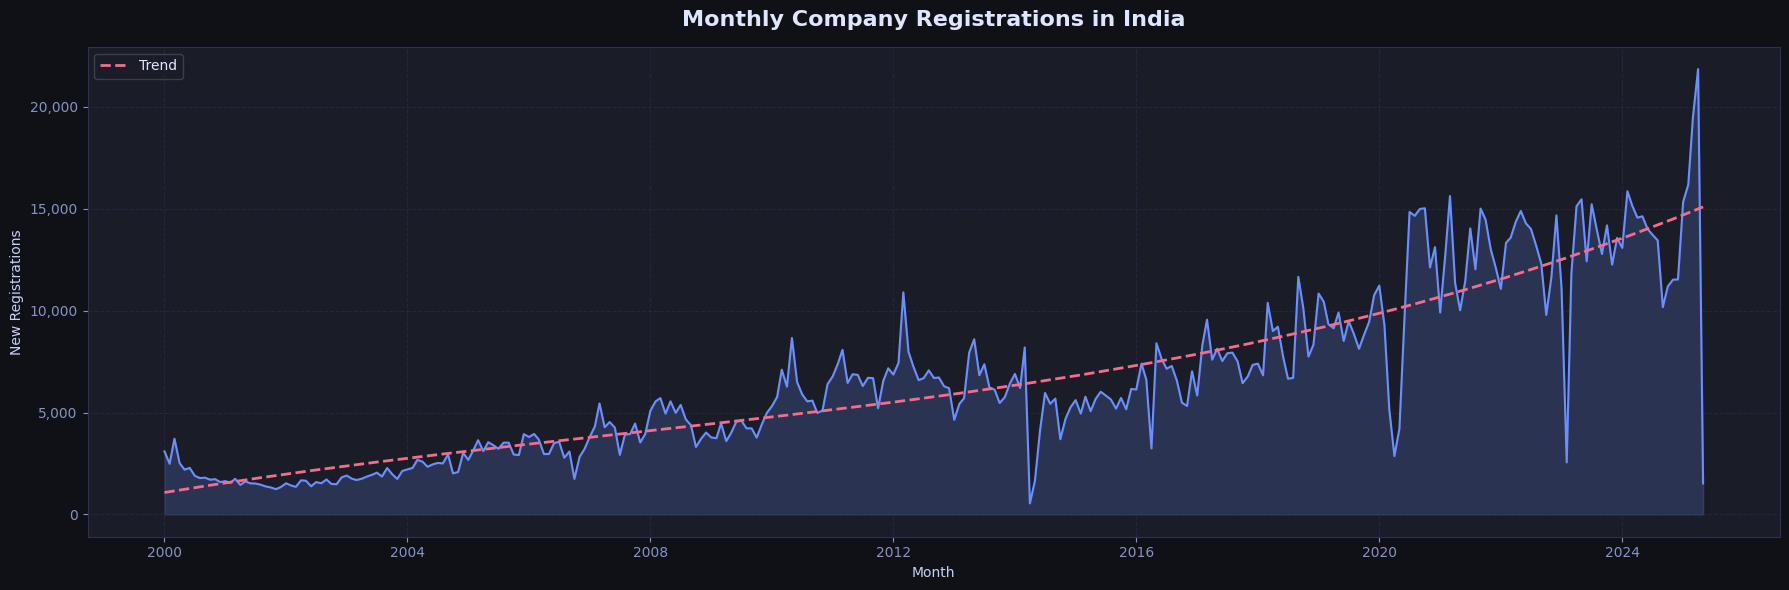

In [13]:
# ── Parse dates & extract month ────────────────────────────────────
merged_df['CompanyRegistrationdate_date'] = pd.to_datetime(
    merged_df['CompanyRegistrationdate_date'], errors='coerce'
)
merged_df['YearMonth'] = merged_df['CompanyRegistrationdate_date'].dt.to_period('M')
 
# ── Monthly count ──────────────────────────────────────────────────
monthly = (
    merged_df.groupby('YearMonth')
    .size()
    .reset_index(name='Registrations')
    .sort_values('YearMonth')
)
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()
 
# ── Filter to 2000 onwards for clarity (adjust if needed) ──────────
monthly = monthly[monthly['YearMonth_dt'] >= '2000-01-01']
 
# ── Plot ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1f5',
    'xtick.color':      '#8892c4',
    'ytick.color':      '#8892c4',
    'text.color':       '#e0e6ff',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
 
fig, ax = plt.subplots(figsize=(18, 6))
 
ax.fill_between(monthly['YearMonth_dt'], monthly['Registrations'],
                alpha=0.2, color='#6c8fff')
ax.plot(monthly['YearMonth_dt'], monthly['Registrations'],
        color='#6c8fff', linewidth=1.5)
 
 
# ── Trend line (polynomial degree 3) ──────────────────────────────
x_numeric = np.arange(len(monthly))
z = np.polyfit(x_numeric, monthly['Registrations'], 3)
p = np.poly1d(z)
ax.plot(monthly['YearMonth_dt'], p(x_numeric),
        color='#f76c8a', linewidth=2, linestyle='--', label='Trend')
ax.legend(fontsize=10, framealpha=0.2)
 
ax.set_title('Monthly Company Registrations in India', fontsize=16,
             fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('New Registrations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True)
 
plt.tight_layout()
plt.show()

In [14]:
print(f"The least number of registrations in a month is {monthly['Registrations'].min()} in {monthly.loc[monthly['Registrations'].idxmin(), 'YearMonth_dt'].strftime('%Y-%m')}")
print(f"The highest number of registrations in a month is {monthly['Registrations'].max()} in {monthly.loc[monthly['Registrations'].idxmax(), 'YearMonth_dt'].strftime('%Y-%m')}")
print(f"The average number of registrations per month is {monthly['Registrations'].mean():,.0f}")

The least number of registrations in a month is 545 in 2014-04
The highest number of registrations in a month is 21851 in 2025-04
The average number of registrations per month is 6,549


In [22]:
# Define the category mapping
status_category_map = {
    # Active
    'Active': 'Active',
    
    # Technically Exists but Dysfunctional
    'Dormant under section 455': 'Technically Exists but Dysfunctional',
    'Inactive': 'Technically Exists but Dysfunctional',
    'Inactive for e-filing': 'Technically Exists but Dysfunctional',
    'Not available for efiling': 'Technically Exists but Dysfunctional',
    
    # Heading to Closure
    'Under CIRP': 'Heading to Closure',
    'Under Liquidation': 'Heading to Closure',
    'Under process of striking off': 'Heading to Closure',
    'Strike Off-AwaitingPublication': 'Heading to Closure',
    
    # Permanently Closed
    'Strike Off': 'Permanently Closed',
    'Dissolved': 'Permanently Closed',
    'Dissolved (Liquidated)': 'Permanently Closed',
    'Dissolved under section 59(8)': 'Permanently Closed',
    'Dissolved under section 54': 'Permanently Closed',
    'Amalgamated': 'Permanently Closed',
    'Converted to LLP': 'Permanently Closed',
    'Converted to LLP and Dissolved': 'Permanently Closed',
    'Vanished': 'Permanently Closed',
    
    # Unknown
    'Unclassified': 'Unknown',
}

# Apply mapping to create new column
merged_df['CompanyStatus_category'] = merged_df['CompanyStatus'].map(status_category_map).fillna('Unknown')

# Verify
print(merged_df['CompanyStatus_category'].value_counts())
print("\nAny unmapped statuses:")
print(merged_df[merged_df['CompanyStatus_category'] == 'Unknown']['CompanyStatus'].unique())

CompanyStatus_category
Active                                  1624297
Permanently Closed                       791436
Heading to Closure                        33326
Technically Exists but Dysfunctional       9092
Unknown                                       1
Name: count, dtype: int64

Any unmapped statuses:
['Unclassified']


In [23]:
status_counts = merged_df['CompanyStatus_category'].value_counts()
status_percentages = merged_df['CompanyStatus_category'].value_counts(normalize=True) * 100

print("Counts:")
print(status_counts)
print("\nPercentages:")
print(status_percentages.round(2).astype(str) + '%')

Counts:
CompanyStatus_category
Active                                  1624297
Permanently Closed                       791436
Heading to Closure                        33326
Technically Exists but Dysfunctional       9092
Unknown                                       1
Name: count, dtype: int64

Percentages:
CompanyStatus_category
Active                                  66.08%
Permanently Closed                       32.2%
Heading to Closure                       1.36%
Technically Exists but Dysfunctional     0.37%
Unknown                                   0.0%
Name: proportion, dtype: object


In [24]:
merged_df.head()

,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State,YearMonth,CompanyStatus_category
0,U55100AN2009PTC000115,U AND I RESORTS PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,989630.0,2009-06-18,"HAVELOCK,PORT BLAIR,Andaman and Nicobar Island...",Unlisted,Active,andaman and nicobar islands,Indian,55100,Trading,andaman and nicobar islands,2009-06,Active
1,U55200AN2021PTC005554,JUNGLEVILLA RESORT & SPA PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1500000.0,100000.0,2021-10-13,"C/O BINITH DAS, 01, OPP. GOLDEN PEBBLE GOVIN...",Unlisted,Active,andaman and nicobar islands,Indian,55200,Trading,andaman and nicobar islands,2021-10,Active
2,U55209AN2018PTC005409,CORAL ISLAND BEACH RESORT PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,2000000.0,200000.0,2018-05-31,"GOVINDA NAGAR PORT BLAIR SOUTH ANDAMAN,PORT ...",Unlisted,Active,andaman and nicobar islands,Indian,55209,Trading,andaman and nicobar islands,2018-05,Active
3,U63031AN2019PTC005474,INFO INDIA TOUR AND HOLIDAYS PRIVATE LIMITED,ROC Chennai,Company limited by shares,Non-government company,Private,10000.0,10000.0,2019-11-21,"C/o Kulandai Velu, C-18, V/Nagar Bambooflat,...",Unlisted,Active,andaman and nicobar islands,Indian,63031,"Transport, storage and Communications",andaman and nicobar islands,2019-11,Active
4,U63040AN1999PTC000061,ANDAMAN TOURIST COTTAGE PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,10000.0,1999-04-26,"Babu Lane Port Blair,NA,Andaman and Nicobar ...",Unlisted,Strike Off,andaman and nicobar islands,Indian,63040,"Transport, storage and Communications",andaman and nicobar islands,1999-04,Permanently Closed
